# 03 — Modelagem LSTM

**Seção 4**:
- **Etapa A**: Baseline LSTM
- **Etapa B**: 4 variações arquiteturais (B1-B4)
- **Etapa C**: Otimização Optuna
- **Etapa D**: Modelo final + Walk-Forward Validation

Observabilidade: MLflow + TensorBoard (Seção 4.4)

In [1]:
import sys, os, logging, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import tensorflow as tf

sys.path.insert(0, os.path.abspath('..'))
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs disponíveis: {tf.config.list_physical_devices('GPU')}")

d:\5. Academia\4. Machine Learning Engineering - FIAP\projeto_4\lstm_financial\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.21.0


2026-04-21 16:34:20,544 - tensorflow - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


GPUs disponíveis: []


In [2]:
# Carregar dados preparados na etapa 02
data = np.load('../data/processed/sequences.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']

with open('../data/processed/metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val:   X={X_val.shape}, y={y_val.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")
print(f"Input shape: {X_train.shape[1:]}")

Train: X=(2832, 60, 75), y=(2832,)
Val:   X=(560, 60, 75), y=(560,)
Test:  X=(560, 60, 75), y=(560,)
Input shape: (60, 75)


In [3]:
# Setup MLflow
from src.utils.mlflow_utils import setup_mlflow
setup_mlflow(experiment_name='lstm_financial_petr4')

2026-04-21 16:34:24,230 - src.utils.mlflow_utils - INFO - MLflow tracking URI: sqlite:///mlflow.db
2026-04-21 16:34:24,231 - src.utils.mlflow_utils - INFO - MLflow experiment: 'lstm_financial_petr4' (ID: 1)


'1'

---
## Etapa A — Baseline LSTM

Hiperparâmetros fixos: lr=0.001, batch=64, T=60

In [4]:
from src.model.builder import build_model
from src.model.trainer import train_model
from src.evaluation.metrics import compute_classification_metrics, log_classification_to_mlflow
from src.evaluation.backtester import Backtester

input_shape = X_train.shape[1:]  # (timesteps, features)

# Construir e treinar baseline
model_a = build_model('baseline', input_shape)
model_a.summary()

Model: "baseline_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 75)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 128)        │       104,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 60, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,737 (612.25 KB)

 Trainable params: 156,353 (610.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [5]:
model_a, history_a = train_model(
    model=model_a,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    run_name='etapa_A_baseline',
    learning_rate=0.001,
    batch_size=64,
    epochs=200,
    logs_dir='../logs',
    models_dir='../models',
    tags={'stage': 'A', 'architecture': 'baseline'},
)

2026-04-21 16:34:27,210 - src.model.trainer - INFO - Class weights: {0: 1.032069970845481, 1: 0.9698630136986301}
2026-04-21 16:34:27,211 - src.model.trainer - INFO - 
2026-04-21 16:34:27,212 - src.model.trainer - INFO - TREINAMENTO: etapa_A_baseline
2026-04-21 16:34:27,212 - src.model.trainer - INFO - ============================================================
2026-04-21 16:34:27,212 - src.model.trainer - INFO -   Arquitetura: baseline_lstm
2026-04-21 16:34:27,213 - src.model.trainer - INFO -   Input shape: (60, 75)
2026-04-21 16:34:27,213 - src.model.trainer - INFO -   LR: 0.001, Batch: 64, Max epochs: 200
2026-04-21 16:34:27,213 - src.model.trainer - INFO -   Train: 2832, Val: 560


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.5046 - loss: 0.8627 - val_accuracy: 0.4393 - val_loss: 0.7564 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5240 - loss: 0.7897 - val_accuracy: 0.4750 - val_loss: 0.7521 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5081 - loss: 0.7800 - val_accuracy: 0.4857 - val_loss: 0.7512 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5328 - loss: 0.7624 - val_accuracy: 0.5018 - val_loss: 0.7504 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.5290 - loss: 0.7584 - val_accuracy: 0.4643 - val_loss: 0.7556 - learning_rate: 0.0010
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5367 - loss: 0.7506 - val_accuracy: 0.5036 - val_loss: 0.7516 - learning_rate: 0.0010
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.5275 - loss: 0.7531 - 

2026/04/21 16:35:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 16:35:22 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-04-21 16:35:38,910 - src.model.trainer - INFO -   MLflow run ID: efc0539e8f374ccbb40d939f9567381c
2026-04-21 16:35:39,030 - src.model.trainer - INFO - 
  Melhor época: 3
2026-04-21 16:35:39,031 - src.model.trainer - INFO -   Val Loss: 0.7504
2026-04-21 16:35:39,031 - src.model.trainer - INFO -   Val Accuracy: 0.5018


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


2026-04-21 16:35:39,728 - src.evaluation.metrics - INFO - Métricas de classificação:
2026-04-21 16:35:39,729 - src.evaluation.metrics - INFO -   accuracy: 0.5018
2026-04-21 16:35:39,729 - src.evaluation.metrics - INFO -   precision: 0.6084
2026-04-21 16:35:39,729 - src.evaluation.metrics - INFO -   recall: 0.3206
2026-04-21 16:35:39,730 - src.evaluation.metrics - INFO -   f1_score: 0.4200
2026-04-21 16:35:39,730 - src.evaluation.metrics - INFO -   auc_roc: 0.5363
2026-04-21 16:35:39,730 - src.evaluation.metrics - INFO -   log_loss: 0.6973
2026-04-21 16:35:40,293 - src.evaluation.backtester - INFO - Backtest executado com sucesso.
2026-04-21 16:35:40,295 - src.evaluation.backtester - INFO - Métricas financeiras:
2026-04-21 16:35:40,295 - src.evaluation.backtester - INFO -   retorno_acumulado_pct: 41.02
2026-04-21 16:35:40,296 - src.evaluation.backtester - INFO -   retorno_bh_pct: 224.43
2026-04-21 16:35:40,296 - src.evaluation.backtester - INFO -   cagr_pct: 16.73
2026-04-21 16:35:40,29

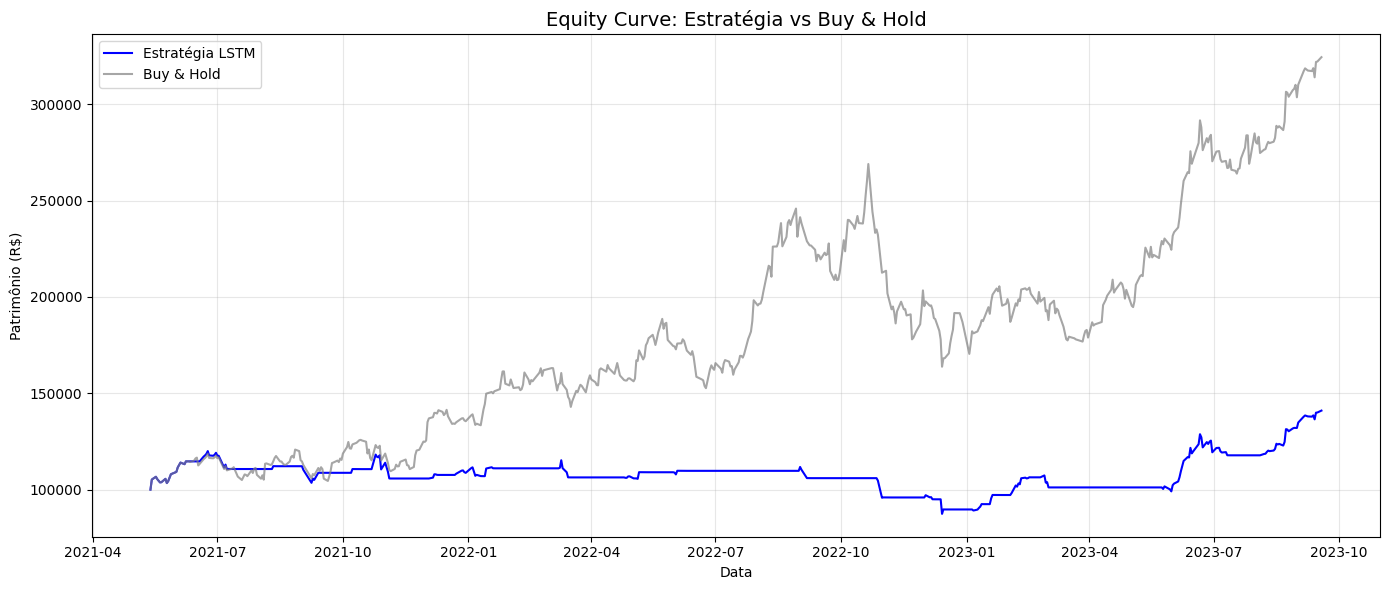

2026-04-21 16:35:41,071 - src.evaluation.backtester - INFO - Drawdown plot salvo: ../reports/etapa_A_baseline/drawdown.png


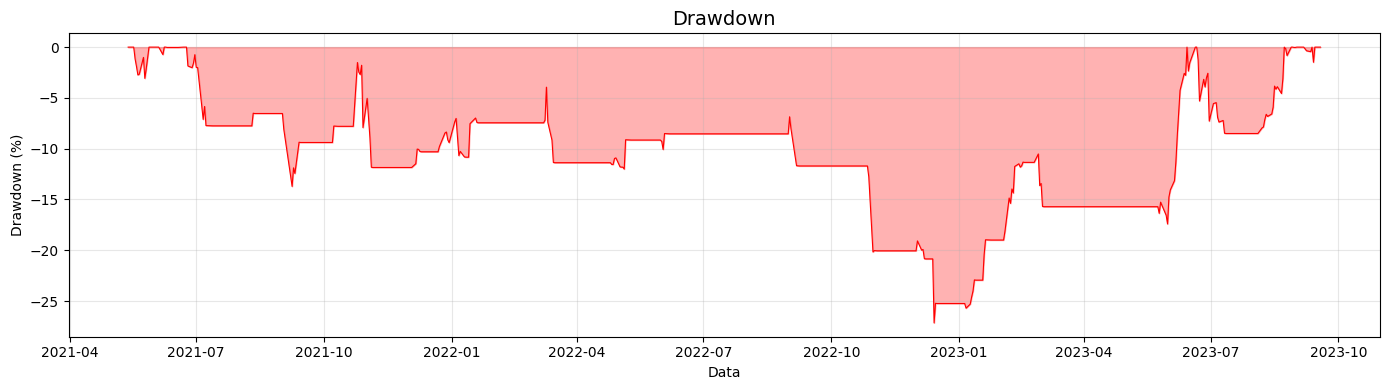

2026-04-21 16:35:41,156 - src.evaluation.backtester - INFO - Relatório salvo: ..\reports\etapa_A_baseline\relatorio_backtest.md


'# Relatório de Backtest\n\n## Métricas Financeiras\n\n| Métrica | Valor |\n|---|---|\n| Retorno Acumulado | 41.02% |\n| Retorno Buy & Hold | 224.43% |\n| CAGR | 16.73% |\n| Sharpe Ratio | 0.2307 |\n| Sortino Ratio | 0.1617 |\n| Max Drawdown | -27.15% |\n| Win Rate | 58.43% |\n| Profit Factor | 1.3378 |\n| Calmar Ratio | 0.6160 |\n| Nº de Trades | 50 |\n| Dias no Período | 560 |\n\n## Configuração\n- Capital Inicial: R$ 100,000.00\n- Custo por Transação: 0.030%\n- Período: 2021-05-13 a 2023-09-18\n'

In [6]:
# Avaliar e backtest na validação
y_pred_a = model_a.predict(X_val).flatten()
metrics_a = compute_classification_metrics(y_val, y_pred_a)

# Calcular retornos reais para backtest
# Carregar features e preços para obter retornos
df_features = pd.read_csv('../data/processed/features.csv', index_col=0, parse_dates=True)
petr4_clean = pd.read_csv('../data/processed/petr4_clean.csv', index_col=0, parse_dates=True)

val_dates = [pd.Timestamp(d) for d in metadata['dates']['val']]
val_returns = petr4_clean.loc[val_dates, 'Close'].pct_change().fillna(0).values
val_prices = petr4_clean.loc[val_dates, 'Close'].values

bt_a = Backtester(
    predictions=(y_pred_a >= 0.5).astype(int),
    actual_returns=val_returns,
    dates=val_dates,
    actual_prices=val_prices,
)
bt_a.run()
bt_metrics_a = bt_a.get_metrics()
fig = bt_a.plot_results(save_path='../reports/etapa_A_baseline/equity_curve.png')
plt.show()
fig = bt_a.plot_drawdown(save_path='../reports/etapa_A_baseline/drawdown.png')
plt.show()
bt_a.generate_report('../reports/etapa_A_baseline')

---
## Etapa B — Teste de Arquiteturas Alternativas

Mesmos hiperparâmetros da Etapa A para comparação justa.

In [7]:
architectures_b = {
    'B1_attention': 'attention',
    'B2_conv1d_lstm': 'conv1d_lstm',
    'B3_bidirectional': 'bidirectional',
    'B4_lstm_gru': 'lstm_gru',
}

results_b = {}

for label, arch_name in architectures_b.items():
    print(f"\n{'='*60}")
    print(f"Treinando {label} ({arch_name})")
    print(f"{'='*60}")
    
    model_b = build_model(arch_name, input_shape)
    model_b, history_b = train_model(
        model=model_b,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        run_name=f'etapa_{label}',
        learning_rate=0.001,
        batch_size=64,
        epochs=200,
        logs_dir='../logs',
        models_dir='../models',
        tags={'stage': 'B', 'architecture': arch_name, 'variant': label},
    )
    
    # Avaliar
    y_pred_b = model_b.predict(X_val).flatten()
    cls_metrics = compute_classification_metrics(y_val, y_pred_b)
    
    # Backtest
    report_dir = f'../reports/etapa_{label}'.replace('B1', 'B1').lower()
    # Mapear nomes de diretório
    dir_map = {
        'B1_attention': 'etapa_B1_attention',
        'B2_conv1d_lstm': 'etapa_B2_conv1d_lstm',
        'B3_bidirectional': 'etapa_B3_bidirectional',
        'B4_lstm_gru': 'etapa_B4_lstm_gru',
    }
    report_dir = f'../reports/{dir_map[label]}'
    
    bt_b = Backtester(
        predictions=(y_pred_b >= 0.5).astype(int),
        actual_returns=val_returns,
        dates=val_dates,
        actual_prices=val_prices,
    )
    bt_b.run()
    bt_met = bt_b.get_metrics()
    bt_b.plot_results(save_path=f'{report_dir}/equity_curve.png')
    bt_b.plot_drawdown(save_path=f'{report_dir}/drawdown.png')
    bt_b.generate_report(report_dir)
    plt.close('all')
    
    results_b[label] = {
        'classification': cls_metrics,
        'backtest': bt_met,
        'model': model_b,
    }
    
    # Limpar sessão
    tf.keras.backend.clear_session()

2026-04-21 16:35:41,217 - src.model.trainer - INFO - Class weights: {0: 1.032069970845481, 1: 0.9698630136986301}
2026-04-21 16:35:41,218 - src.model.trainer - INFO - 
2026-04-21 16:35:41,219 - src.model.trainer - INFO - TREINAMENTO: etapa_B1_attention
2026-04-21 16:35:41,219 - src.model.trainer - INFO - ============================================================
2026-04-21 16:35:41,219 - src.model.trainer - INFO -   Arquitetura: attention_lstm
2026-04-21 16:35:41,219 - src.model.trainer - INFO -   Input shape: (60, 75)
2026-04-21 16:35:41,220 - src.model.trainer - INFO -   LR: 0.001, Batch: 64, Max epochs: 200
2026-04-21 16:35:41,220 - src.model.trainer - INFO -   Train: 2832, Val: 560



Treinando B1_attention (attention)
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.4929 - loss: 0.7760 - val_accuracy: 0.4554 - val_loss: 0.7782 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.5092 - loss: 0.7558 - val_accuracy: 0.4375 - val_loss: 0.8460 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.5279 - loss: 0.7493 - val_accuracy: 0.4661 - val_loss: 0.7557 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.5113 - loss: 0.7474 - val_accuracy: 0.4589 - val_loss: 0.7899 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.5339 - loss: 0.7390 - val_accuracy: 0.4571 - val_loss: 0.7817 - learning_rate: 0.0010
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.5413 - loss: 0.7371 - val_accuracy: 0.4482 - val_loss: 0.7866 - learning_rate: 0.0010
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step 

2026/04/21 16:37:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 16:37:13 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-04-21 16:37:21,998 - src.model.trainer - INFO -   MLflow run ID: 7f2bce4843c547adbe9d9192e4cf1722
2026-04-21 16:37:22,133 - src.model.trainer - INFO - 
  Melhor época: 14
2026-04-21 16:37:22,134 - src.model.trainer - INFO -   Val Loss: 0.7364
2026-04-21 16:37:22,134 - src.model.trainer - INFO -   Val Accuracy: 0.4768


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


2026-04-21 16:37:22,790 - src.evaluation.metrics - INFO - Métricas de classificação:
2026-04-21 16:37:22,791 - src.evaluation.metrics - INFO -   accuracy: 0.4768
2026-04-21 16:37:22,791 - src.evaluation.metrics - INFO -   precision: 0.6058
2026-04-21 16:37:22,791 - src.evaluation.metrics - INFO -   recall: 0.2000
2026-04-21 16:37:22,792 - src.evaluation.metrics - INFO -   f1_score: 0.3007
2026-04-21 16:37:22,792 - src.evaluation.metrics - INFO -   auc_roc: 0.5131
2026-04-21 16:37:22,792 - src.evaluation.metrics - INFO -   log_loss: 0.7019
2026-04-21 16:37:22,794 - src.evaluation.backtester - INFO - Backtest executado com sucesso.
2026-04-21 16:37:22,796 - src.evaluation.backtester - INFO - Métricas financeiras:
2026-04-21 16:37:22,796 - src.evaluation.backtester - INFO -   retorno_acumulado_pct: 78.34
2026-04-21 16:37:22,797 - src.evaluation.backtester - INFO -   retorno_bh_pct: 224.43
2026-04-21 16:37:22,797 - src.evaluation.backtester - INFO -   cagr_pct: 29.74
2026-04-21 16:37:22,79

...

2026-04-21 16:39:34,445 - src.evaluation.metrics - INFO - Métricas de classificação:
2026-04-21 16:39:34,446 - src.evaluation.metrics - INFO -   accuracy: 0.5304
2026-04-21 16:39:34,446 - src.evaluation.metrics - INFO -   precision: 0.5844
2026-04-21 16:39:34,446 - src.evaluation.metrics - INFO -   recall: 0.5714
2026-04-21 16:39:34,447 - src.evaluation.metrics - INFO -   f1_score: 0.5778
2026-04-21 16:39:34,447 - src.evaluation.metrics - INFO -   auc_roc: 0.5484
2026-04-21 16:39:34,447 - src.evaluation.metrics - INFO -   log_loss: 0.6941
2026-04-21 16:39:34,449 - src.evaluation.backtester - INFO - Backtest executado com sucesso.
2026-04-21 16:39:34,451 - src.evaluation.backtester - INFO - Métricas financeiras:
2026-04-21 16:39:34,451 - src.evaluation.backtester - INFO -   retorno_acumulado_pct: 197.16
2026-04-21 16:39:34,452 - src.evaluation.backtester - INFO -   retorno_bh_pct: 224.43
2026-04-21 16:39:34,452 - src.evaluation.backtester - INFO -   cagr_pct: 63.25
2026-04-21 16:39:34,4


Treinando B4_lstm_gru (lstm_gru)
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.4936 - loss: 0.9090 - val_accuracy: 0.5518 - val_loss: 0.7392 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.5081 - loss: 0.8136 - val_accuracy: 0.5482 - val_loss: 0.7413 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5445 - loss: 0.7786 - val_accuracy: 0.5018 - val_loss: 0.7441 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5293 - loss: 0.7758 - val_accuracy: 0.4857 - val_loss: 0.7486 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5219 - loss: 0.7743 - val_accuracy: 0.4750 - val_loss: 0.7571 - learning_rate: 0.0010
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5311 - loss: 0.7629
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - ac

2026/04/21 16:40:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 16:40:12 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-04-21 16:40:20,563 - src.model.trainer - INFO -   MLflow run ID: a5b69a5dc63a4e79b666b4acaa517a65
2026-04-21 16:40:20,711 - src.model.trainer - INFO - 
  Melhor época: 0
2026-04-21 16:40:20,711 - src.model.trainer - INFO -   Val Loss: 0.7392
2026-04-21 16:40:20,711 - src.model.trainer - INFO -   Val Accuracy: 0.5518


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


2026-04-21 16:40:21,279 - src.evaluation.metrics - INFO - Métricas de classificação:
2026-04-21 16:40:21,280 - src.evaluation.metrics - INFO -   accuracy: 0.5518
2026-04-21 16:40:21,280 - src.evaluation.metrics - INFO -   precision: 0.5630
2026-04-21 16:40:21,281 - src.evaluation.metrics - INFO -   recall: 0.9079
2026-04-21 16:40:21,281 - src.evaluation.metrics - INFO -   f1_score: 0.6950
2026-04-21 16:40:21,282 - src.evaluation.metrics - INFO -   auc_roc: 0.5082
2026-04-21 16:40:21,282 - src.evaluation.metrics - INFO -   log_loss: 0.6872
2026-04-21 16:40:21,284 - src.evaluation.backtester - INFO - Backtest executado com sucesso.
2026-04-21 16:40:21,285 - src.evaluation.backtester - INFO - Métricas financeiras:
2026-04-21 16:40:21,286 - src.evaluation.backtester - INFO -   retorno_acumulado_pct: 192.45
2026-04-21 16:40:21,286 - src.evaluation.backtester - INFO -   retorno_bh_pct: 224.43
2026-04-21 16:40:21,287 - src.evaluation.backtester - INFO -   cagr_pct: 62.08
2026-04-21 16:40:21,2

In [9]:
# Tabela comparativa Etapas A + B
comparison = []

# Etapa A
comparison.append({
    'Modelo': 'A - Baseline',
    'AUC-ROC': metrics_a['auc_roc'],
    'F1': metrics_a['f1_score'],
    'Accuracy': metrics_a['accuracy'],
    'Sharpe': bt_metrics_a['sharpe_ratio'],
    'Sortino': bt_metrics_a['sortino_ratio'],
    'MaxDD%': bt_metrics_a['max_drawdown_pct'],
    'WinRate%': bt_metrics_a['win_rate_pct'],
    'RetAcum%': bt_metrics_a['retorno_acumulado_pct'],
})

# Etapas B
for label, res in results_b.items():
    comparison.append({
        'Modelo': label,
        'AUC-ROC': res['classification']['auc_roc'],
        'F1': res['classification']['f1_score'],
        'Accuracy': res['classification']['accuracy'],
        'Sharpe': res['backtest']['sharpe_ratio'],
        'Sortino': res['backtest']['sortino_ratio'],
        'MaxDD%': res['backtest']['max_drawdown_pct'],
        'WinRate%': res['backtest']['win_rate_pct'],
        'RetAcum%': res['backtest']['retorno_acumulado_pct'],
    })

df_comparison = pd.DataFrame(comparison)
display(df_comparison.sort_values('AUC-ROC', ascending=False))

# Salvar
df_comparison.to_csv('../reports/tabela_comparativa_AB.csv', index=False)

# Determinar melhor arquitetura
best_row = df_comparison.sort_values('AUC-ROC', ascending=False).iloc[0]
print(f"\n🏆 Melhor modelo: {best_row['Modelo']} (AUC-ROC={best_row['AUC-ROC']:.4f}, Sharpe={best_row['Sharpe']:.4f})")

,Modelo,AUC-ROC,F1,Accuracy,Sharpe,Sortino,MaxDD%,WinRate%,RetAcum%
3,B3_bidirectional,0.548377,0.577849,0.530357,1.4363,1.6548,-19.01,56.49,197.16
0,A - Baseline,0.536301,0.419958,0.501786,0.2307,0.1617,-27.15,58.43,41.02
1,B1_attention,0.513068,0.300716,0.476786,0.9132,0.6975,-9.89,60.58,78.34
4,B4_lstm_gru,0.508202,0.695018,0.551786,1.1666,1.5894,-26.53,55.51,192.45
2,B2_conv1d_lstm,0.486764,0.647137,0.526786,1.1148,1.4505,-22.69,54.82,159.51



🏆 Melhor modelo: B3_bidirectional (AUC-ROC=0.5484, Sharpe=1.4363)


---
## Etapa C — Otimização de Hiperparâmetros (Optuna)

Usar a arquitetura vencedora da etapa anterior.

In [12]:
from src.model.tuner import run_optuna_optimization

# Definir a melhor arquitetura manualmente após análise da tabela acima
# (ajustar conforme resultado real)
BEST_ARCHITECTURE = 'bidirectional'  # ← AJUSTAR após análise das etapas A/B ['baseline', 'attention', 'conv1d_lstm', 'bidirectional', 'lstm_gru']

print(f"Arquitetura selecionada para otimização: {BEST_ARCHITECTURE}")
print(f"Iniciando Optuna com 50 trials...")

study, best_params = run_optuna_optimization(
    architecture=BEST_ARCHITECTURE,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    n_trials=50,
)

print(f"\nMelhores hiperparâmetros:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nMelhor AUC-ROC: {study.best_value:.4f}")

2026-04-21 16:44:44,761 - src.model.tuner - INFO - ============================================================
2026-04-21 16:44:44,761 - src.model.tuner - INFO - OTIMIZAÇÃO DE HIPERPARÂMETROS (Etapa C)
2026-04-21 16:44:44,761 - src.model.tuner - INFO - Arquitetura: bidirectional, Trials: 50
2026-04-21 16:44:44,762 - src.model.tuner - INFO - ============================================================


Arquitetura selecionada para otimização: bidirectional
Iniciando Optuna com 50 trials...


[I 2026-04-21 16:44:45,242] A new study created in memory with name: lstm_bidirectional_optimization
Best trial: 0. Best value: 0.494512:   2%|▏         | 1/50 [01:06<54:33, 66.80s/it]

[I 2026-04-21 16:45:52,038] Trial 0 finished with value: 0.49451247165532874 and parameters: {'window_size': 30, 'lstm1_units': 128, 'lstm2_units': 128, 'dense_units': 64, 'dropout_lstm': 0.19272429965590102, 'dropout_dense': 0.35822360671372744, 'learning_rate': 0.000122134441528544, 'batch_size': 128, 'use_batchnorm': False, 'l2_reg': 0.00036241762747263957}. Best is trial 0 with value: 0.49451247165532874.


2026-04-21 16:47:34,861 - src.model.tuner - INFO -   Trial 1: AUC-ROC=0.5000
Best trial: 1. Best value: 0.5:   4%|▍         | 2/50 [02:49<1:10:23, 87.99s/it]   

...

[I 2026-04-21 20:01:36,762] Trial 48 finished with value: 0.4841205053449951 and parameters: {'window_size': 60, 'lstm1_units': 224, 'lstm2_units': 32, 'dense_units': 64, 'dropout_lstm': 0.2808136459604747, 'dropout_dense': 0.2787068124669044, 'learning_rate': 0.0011988613975498765, 'batch_size': 32, 'use_batchnorm': False, 'l2_reg': 0.0014000297532891566}. Best is trial 44 with value: 0.5567865241334629.


2026-04-21 20:04:50,262 - src.model.tuner - INFO -   Trial 49: AUC-ROC=0.5304
Best trial: 44. Best value: 0.556787: 100%|██████████| 50/50 [3:20:05<00:00, 240.10s/it]


[I 2026-04-21 20:04:50,263] Trial 49 finished with value: 0.5303790087463557 and parameters: {'window_size': 45, 'lstm1_units': 160, 'lstm2_units': 32, 'dense_units': 32, 'dropout_lstm': 0.38449608670381963, 'dropout_dense': 0.1206519535702397, 'learning_rate': 0.00172921399972208, 'batch_size': 64, 'use_batchnorm': True, 'l2_reg': 0.00015365598722685112}. Best is trial 44 with value: 0.5567865241334629.


2026-04-21 20:04:50,638 - src.model.tuner - INFO - 
Melhor AUC-ROC: 0.5568
2026-04-21 20:04:50,639 - src.model.tuner - INFO - Melhores parâmetros: {'window_size': 60, 'lstm1_units': 160, 'lstm2_units': 32, 'dense_units': 16, 'dropout_lstm': 0.3396953278715868, 'dropout_dense': 0.1745209197060034, 'learning_rate': 0.0017745477956381303, 'batch_size': 64, 'use_batchnorm': True, 'l2_reg': 0.0005422292946691238}



Melhores hiperparâmetros:
  window_size: 60
  lstm1_units: 160
  lstm2_units: 32
  dense_units: 16
  dropout_lstm: 0.3396953278715868
  dropout_dense: 0.1745209197060034
  learning_rate: 0.0017745477956381303
  batch_size: 64
  use_batchnorm: True
  l2_reg: 0.0005422292946691238

Melhor AUC-ROC: 0.5568


In [13]:
# Visualização Optuna
import optuna.visualization as vis

fig = vis.plot_optimization_history(study)
fig.show()

fig = vis.plot_param_importances(study)
fig.show()

---
## Etapa D — Modelo Final + Walk-Forward Validation

In [14]:
from src.model.builder import build_model
from src.model.trainer import train_model
from src.utils.serialization import save_model, save_metrics

# Construir modelo final com melhores hiperparâmetros
best_window = best_params.get('window_size', 60)

# Ajustar dados se window_size diferente
if best_window <= X_train.shape[1]:
    X_train_final = X_train[:, -best_window:, :]
    X_val_final = X_val[:, -best_window:, :]
    X_test_final = X_test[:, -best_window:, :]
else:
    X_train_final, X_val_final, X_test_final = X_train, X_val, X_test

input_shape_final = X_train_final.shape[1:]

build_kwargs = {
    'dense_units': best_params.get('dense_units', 32),
    'dropout_lstm': best_params.get('dropout_lstm', 0.3),
    'dropout_dense': best_params.get('dropout_dense', 0.2),
    'use_batchnorm': best_params.get('use_batchnorm', True),
}
if BEST_ARCHITECTURE in ('baseline', 'attention', 'conv1d_lstm', 'bidirectional'):
    build_kwargs['lstm1_units'] = best_params.get('lstm1_units', 128)
    build_kwargs['lstm2_units'] = best_params.get('lstm2_units', 64)
elif BEST_ARCHITECTURE == 'lstm_gru':
    build_kwargs['lstm_units'] = best_params.get('lstm1_units', 128)
    build_kwargs['gru_units'] = best_params.get('lstm2_units', 64)

model_final = build_model(BEST_ARCHITECTURE, input_shape_final, **build_kwargs)
model_final.summary()

Model: "bidirectional_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 75)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 60, 320)        │       302,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 60, 320)        │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 320)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 64)             │        90,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395,041 (1.51 MB)

 Trainable params: 394,273 (1.50 MB)

 Non-trainable params: 768 (3.00 KB)

In [15]:
model_final, history_final = train_model(
    model=model_final,
    X_train=X_train_final, y_train=y_train,
    X_val=X_val_final, y_val=y_val,
    run_name='etapa_D_modelo_final',
    learning_rate=best_params.get('learning_rate', 0.001),
    batch_size=best_params.get('batch_size', 64),
    epochs=200,
    logs_dir='../logs',
    models_dir='../models',
    tags={'stage': 'D', 'architecture': BEST_ARCHITECTURE, 'status': 'final'},
)

2026-04-21 20:04:53,279 - src.model.trainer - INFO - Class weights: {0: 1.032069970845481, 1: 0.9698630136986301}
2026-04-21 20:04:53,280 - src.model.trainer - INFO - 
2026-04-21 20:04:53,280 - src.model.trainer - INFO - TREINAMENTO: etapa_D_modelo_final
2026-04-21 20:04:53,280 - src.model.trainer - INFO - ============================================================
2026-04-21 20:04:53,281 - src.model.trainer - INFO -   Arquitetura: bidirectional_lstm
2026-04-21 20:04:53,281 - src.model.trainer - INFO -   Input shape: (60, 75)
2026-04-21 20:04:53,281 - src.model.trainer - INFO -   LR: 0.0017745477956381303, Batch: 64, Max epochs: 200
2026-04-21 20:04:53,281 - src.model.trainer - INFO -   Train: 2832, Val: 560


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 255ms/step - accuracy: 0.5060 - loss: 0.9523 - val_accuracy: 0.4750 - val_loss: 0.8094 - learning_rate: 0.0018
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 238ms/step - accuracy: 0.4947 - loss: 0.8715 - val_accuracy: 0.4321 - val_loss: 0.8295 - learning_rate: 0.0018
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 238ms/step - accuracy: 0.5187 - loss: 0.8377 - val_accuracy: 0.4714 - val_loss: 0.8112 - learning_rate: 0.0018
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 234ms/step - accuracy: 0.5074 - loss: 0.8244 - val_accuracy: 0.4804 - val_loss: 0.8085 - learning_rate: 0.0018
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 233ms/step - accuracy: 0.5230 - loss: 0.8157 - val_accuracy: 0.4714 - val_loss: 0.8121 - learning_rate: 0.0018
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.5297 - loss: 0.8041 - val_accuracy: 0.5357 - val_loss: 0.7922 - learning_rate: 0.0018
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.5237 - l

2026/04/21 20:12:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 20:12:17 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-04-21 20:12:28,557 - src.model.trainer - INFO -   MLflow run ID: e732c6aac38d4c79800ad8d5d4fa688f
2026-04-21 20:12:29,036 - src.model.trainer - INFO - 
  Melhor época: 25
2026-04-21 20:12:29,036 - src.model.trainer - INFO -   Val Loss: 0.7680
2026-04-21 20:12:29,037 - src.model.trainer - INFO -   Val Accuracy: 0.5250


In [17]:
# Avaliar modelo final no conjunto de teste
y_pred_test = model_final.predict(X_test_final).flatten()
test_cls_metrics = compute_classification_metrics(y_test, y_pred_test)

print("Métricas no conjunto de teste:")
for k, v in test_cls_metrics.items():
    print(f"  {k}: {v:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


2026-04-21 20:36:30,354 - src.evaluation.metrics - INFO - Métricas de classificação:
2026-04-21 20:36:30,355 - src.evaluation.metrics - INFO -   accuracy: 0.4929
2026-04-21 20:36:30,355 - src.evaluation.metrics - INFO -   precision: 0.5288
2026-04-21 20:36:30,356 - src.evaluation.metrics - INFO -   recall: 0.5183
2026-04-21 20:36:30,356 - src.evaluation.metrics - INFO -   f1_score: 0.5235
2026-04-21 20:36:30,356 - src.evaluation.metrics - INFO -   auc_roc: 0.5053
2026-04-21 20:36:30,356 - src.evaluation.metrics - INFO -   log_loss: 0.6981
2026-04-21 20:36:30,355 - src.evaluation.metrics - INFO -   accuracy: 0.4929
2026-04-21 20:36:30,355 - src.evaluation.metrics - INFO -   precision: 0.5288
2026-04-21 20:36:30,356 - src.evaluation.metrics - INFO -   recall: 0.5183
2026-04-21 20:36:30,356 - src.evaluation.metrics - INFO -   f1_score: 0.5235
2026-04-21 20:36:30,356 - src.evaluation.metrics - INFO -   auc_roc: 0.5053
2026-04-21 20:36:30,356 - src.evaluation.metrics - INFO -   log_loss: 0.

Métricas no conjunto de teste:
  accuracy: 0.4929
  precision: 0.5288
  recall: 0.5183
  f1_score: 0.5235
  auc_roc: 0.5053
  log_loss: 0.6981


In [18]:
# Salvar modelo final
save_model(model_final, '../models/model.keras')
save_metrics(test_cls_metrics, '../models/metrics.json')

print("\n✅ Etapa D concluída — modelo final salvo.")
print("Próximo passo: Etapa E (Backtest Final) no notebook 04.")

2026-04-21 20:36:34,880 - src.utils.serialization - INFO - Modelo salvo: ../models/model.keras
2026-04-21 20:36:34,881 - src.utils.serialization - INFO - Métricas salvas: ../models/metrics.json
2026-04-21 20:36:34,881 - src.utils.serialization - INFO - Métricas salvas: ../models/metrics.json



✅ Etapa D concluída — modelo final salvo.
Próximo passo: Etapa E (Backtest Final) no notebook 04.
